# 03 — EDA cuantitativo

Análisis descriptivo de las variables cuantitativas: las variables crudas de `transactions`, la variable de conteo `repeattrips` y las variables de comportamiento construidas en el notebook 02. Incluye histogramas, diagramas de caja, gráficos de dispersión, la relación de las variables con `repeater`, el análisis de valores atípicos y el manejo de faltantes.

Insumos, todos generados por el notebook 02: `data/processed/dataset_modelo.csv`, la muestra aleatoria del 0.1% de las transacciones y las tablas `results/tables/02_*.csv`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, PercentFormatter

from config import FIGURES_DIR, TABLES_DIR
from preprocesamiento import COLUMNAS_GENERALES, COLUMNAS_OFERTA, cargar_resultados

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", None)

In [2]:
# Paleta validada para daltonismo sobre fondo blanco (azul/naranja: ΔE 24.7 en protanopia)
AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRIS = "#c3c2b7"
TINTA, TINTA_SEC, TINTA_TENUE = "#0b0b0b", "#52514e", "#898781"
REJILLA = "#e1e0d9"
COLOR_CLASE = {False: AZUL, True: NARANJA}
ETIQUETA_CLASE = {False: "No volvió", True: "Volvió"}
SECUENCIAL = LinearSegmentedColormap.from_list(
    "azul", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
        "font.size": 9.5,
        "axes.titlesize": 10.5,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlecolor": TINTA,
        "axes.labelsize": 9,
        "axes.labelcolor": TINTA_SEC,
        "axes.edgecolor": GRIS,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": REJILLA,
        "grid.linewidth": 0.7,
        "grid.linestyle": "-",
        "xtick.color": GRIS,
        "ytick.color": GRIS,
        "xtick.labelcolor": TINTA_SEC,
        "ytick.labelcolor": TINTA_SEC,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.frameon": False,
        "legend.fontsize": 8.5,
        "legend.labelcolor": TINTA_SEC,
        "lines.linewidth": 2,
        "lines.solid_capstyle": "round",
    }
)

miles = FuncFormatter(lambda x, _: f"{x:,.0f}")


def guardar(fig, nombre):
    fig.savefig(FIGURES_DIR / nombre)
    plt.show()


def nota(ax, texto, x=0.98, y=0.96, ha="right"):
    ax.text(x, y, texto, transform=ax.transAxes, ha=ha, va="top", fontsize=8, color=TINTA_SEC)

## 1. Carga

In [3]:
res = cargar_resultados()
ds = res["dataset"]
muestra = res["muestra"]
estadisticas = res["estadisticas"].set_index("variable")
mensual = res["mensual"].assign(mes=lambda d: pd.PeriodIndex(d["mes"], freq="M").to_timestamp())
tasa_global = ds["repeater"].mean()

print("dataset_modelo:", ds.shape)
print("muestra de transacciones:", muestra.shape)
print(f"tasa global de recompra: {tasa_global:.4f}")

dataset_modelo: (160057, 49)
muestra de transacciones: (349163, 11)
tasa global de recompra: 0.2714


## 2. Variables crudas de las transacciones

Las columnas cuantitativas de `transactions` son `purchaseamount`, `purchasequantity` y `productsize`. La media, la desviación, los extremos y los conteos de negativos y ceros son exactos, calculados sobre todas las filas durante la pasada del notebook 02. Los percentiles salen de la muestra aleatoria del 0.1%, que con cientos de miles de filas es suficiente para estimarlos.

In [4]:
cuantiles = muestra[["purchaseamount", "purchasequantity", "productsize"]].quantile([0.01, 0.25, 0.5, 0.75, 0.99]).T
cuantiles.columns = ["p01", "p25", "mediana", "p75", "p99"]
resumen_crudo = estadisticas[["n", "media", "desviacion", "min", "max", "negativos", "ceros"]].join(cuantiles)
resumen_crudo.to_csv(TABLES_DIR / "03_resumen_transacciones_crudas.csv")
resumen_crudo.round(2)

,n,media,desviacion,min,max,negativos,ceros,p01,p25,mediana,p75,p99
variable,,,,,,,,,,,,
purchaseamount,349655789,4.49,878.93,-8593791.0,58658.76,8115002,5422153,-1.0,1.99,3.18,4.99,25.19
purchasequantity,349655789,1.67,40.31,-32255.0,54800.00,273848,518736,1.0,1.00,1.00,2.00,8.00
productsize,349655789,27.33,51.61,0.0,6000.00,0,11507837,0.0,6.50,13.10,24.00,250.00


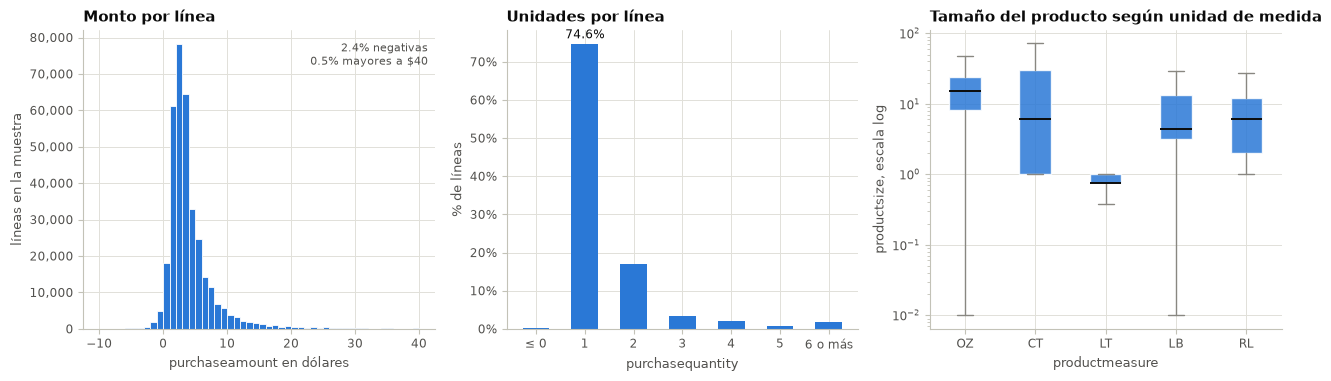

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))

monto = muestra["purchaseamount"]
lim_inf, lim_sup = -10, 40
visibles = monto[(monto >= lim_inf) & (monto <= lim_sup)]
axes[0].hist(visibles, bins=np.arange(lim_inf, lim_sup + 1, 1), color=AZUL, edgecolor="white", linewidth=0.6)
axes[0].set_title("Monto por línea")
axes[0].set_xlabel("purchaseamount en dólares")
axes[0].set_ylabel("líneas en la muestra")
axes[0].yaxis.set_major_formatter(miles)
nota(axes[0], f"{(monto < 0).mean():.1%} negativas\n{(monto > lim_sup).mean():.1%} mayores a ${lim_sup}")

cantidad = muestra["purchasequantity"]
grupos = {"≤ 0": cantidad <= 0, **{str(k): cantidad == k for k in range(1, 6)}, "6 o más": cantidad >= 6}
porcentajes = pd.Series({k: 100 * m.mean() for k, m in grupos.items()})
axes[1].bar(porcentajes.index, porcentajes.values, color=AZUL, width=0.55)
axes[1].set_title("Unidades por línea")
axes[1].set_xlabel("purchasequantity")
axes[1].set_ylabel("% de líneas")
axes[1].yaxis.set_major_formatter(PercentFormatter(decimals=0))
axes[1].text(1, porcentajes["1"] + 1.5, f"{porcentajes['1']:.1f}%", ha="center", fontsize=8.5, color=TINTA)

medidas = ["OZ", "CT", "LT", "LB", "RL"]
tamanos = [muestra.loc[(muestra["productmeasure"] == m) & (muestra["productsize"] > 0), "productsize"] for m in medidas]
caja = axes[2].boxplot(
    tamanos, tick_labels=medidas, widths=0.45, patch_artist=True, showfliers=False,
    medianprops={"color": TINTA, "linewidth": 1.4},
    whiskerprops={"color": TINTA_TENUE}, capprops={"color": TINTA_TENUE},
)
for parche in caja["boxes"]:
    parche.set(facecolor=AZUL, alpha=0.85, edgecolor="white")
axes[2].set_yscale("log")
axes[2].set_title("Tamaño del producto según unidad de medida")
axes[2].set_xlabel("productmeasure")
axes[2].set_ylabel("productsize, escala log")

fig.tight_layout()
guardar(fig, "03_transacciones_crudas.png")

- El monto típico de una línea es bajo: mediana de 3.18 dólares, la mitad central entre 1.99 y 4.99 y percentil 99 de 25.19. La media exacta, 4.49, queda por encima de la mediana por la cola derecha, y la desviación de 879 se debe a unos pocos registros erróneos de millones de dólares.
- El 74.6% de las líneas son de una sola unidad y el 99% tiene 8 unidades o menos.
- El tamaño depende por completo de la unidad: la mediana es 15 en onzas, 6 en conteo, 4.4 en libras y 0.75 en litros. Por eso `productsize` no se usa como variable.

### Componente temporal

Totales por mes de todo el archivo. Las franjas marcan cuándo se entregaron los cupones de train, de marzo a abril de 2013, y de test, de mayo a julio de 2013.

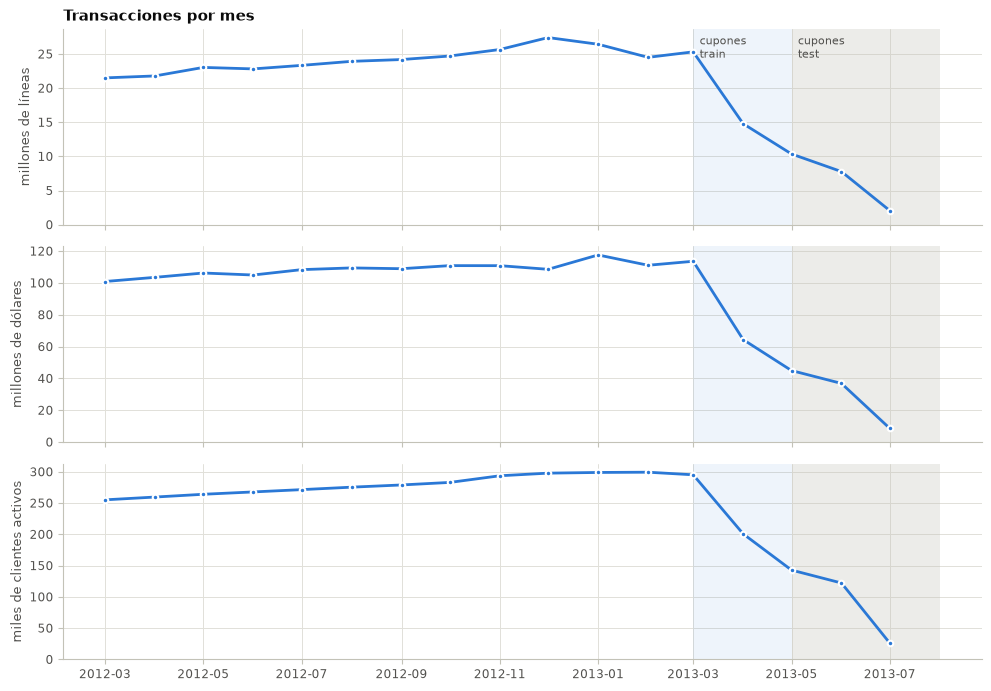

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
series = [
    ("n_lineas", 1e6, "millones de líneas"),
    ("monto", 1e6, "millones de dólares"),
    ("n_clientes", 1e3, "miles de clientes activos"),
]
for ax, (col, escala, etiqueta) in zip(axes, series):
    ax.plot(mensual["mes"], mensual[col] / escala, color=AZUL, marker="o", markersize=4,
            markeredgecolor="white", markeredgewidth=1.5)
    ax.set_ylabel(etiqueta)
    ax.set_ylim(bottom=0)
    ax.axvspan(pd.Timestamp("2013-03-01"), pd.Timestamp("2013-05-01"), color=AZUL, alpha=0.08, lw=0)
    ax.axvspan(pd.Timestamp("2013-05-01"), pd.Timestamp("2013-08-01"), color=GRIS, alpha=0.3, lw=0)
axes[0].text(pd.Timestamp("2013-03-05"), axes[0].get_ylim()[1] * 0.97, "cupones\ntrain", va="top", fontsize=8, color=TINTA_SEC)
axes[0].text(pd.Timestamp("2013-05-05"), axes[0].get_ylim()[1] * 0.97, "cupones\ntest", va="top", fontsize=8, color=TINTA_SEC)
axes[0].set_title("Transacciones por mes")
fig.tight_layout()
guardar(fig, "03_transacciones_mensuales.png")

- De marzo de 2012 a marzo de 2013 el volumen es estable con un leve crecimiento, de 21.5 a 25.3 millones de líneas por mes, con un pico de 27.4 millones en diciembre de 2012 por la temporada navideña. El monto mensual se mantiene entre 100 y 118 millones de dólares.
- Desde abril de 2013 la serie cae hasta 2.1 millones de líneas en julio. No es una baja en las ventas: el historial de cada cliente termina el día de su oferta, así que en los meses de cupones solo siguen activos los clientes con ofertas posteriores. Los clientes activos pasan de 299 mil en febrero a 26 mil en julio.
- Consecuencia: los clientes de test, con ofertas de mayo a julio, tienen más historial que los de train, y las variables acumuladas sobre todo el historial no son comparables entre ambos conjuntos. Se cuantifica en la sección 9.

## 3. Variable de conteo `repeattrips`

`repeattrips` es el número de veces que el cliente volvió a comprar el producto ofertado; `repeater` es simplemente `repeattrips > 0`.

In [7]:
rt = ds["repeattrips"]
rangos = pd.cut(rt, bins=[-1, 0, 1, 2, 3, 5, 10, np.inf], labels=["0", "1", "2", "3", "4 a 5", "6 a 10", "11 o más"])
frecuencias_rt = rangos.value_counts(sort=False).rename("clientes").to_frame()
frecuencias_rt["porcentaje"] = (100 * frecuencias_rt["clientes"] / len(ds)).round(2)
frecuencias_rt.to_csv(TABLES_DIR / "03_repeattrips_frecuencias.csv")
frecuencias_rt

,clientes,porcentaje
repeattrips,,
0,116619,72.86
1,24742,15.46
2,8269,5.17
3,3646,2.28
4 a 5,3387,2.12
6 a 10,2408,1.50
11 o más,986,0.62


In [8]:
resumen_rt = pd.DataFrame(
    {
        "todos": rt.describe(percentiles=[0.5, 0.9, 0.99, 0.999]),
        "solo_recurrentes": rt[rt > 0].describe(percentiles=[0.5, 0.9, 0.99, 0.999]),
    }
)
resumen_rt.loc["asimetria"] = [rt.skew(), rt[rt > 0].skew()]
resumen_rt.to_csv(TABLES_DIR / "03_repeattrips_resumen.csv")
resumen_rt.round(2)

,todos,solo_recurrentes
count,160057.00,43438.00
mean,0.66,2.42
std,6.79,12.86
min,0.00,1.00
50%,0.00,1.00
90%,2.00,5.00
99%,8.00,15.00
99.9%,20.00,30.00
max,2124.00,2124.00
asimetria,251.78,135.85


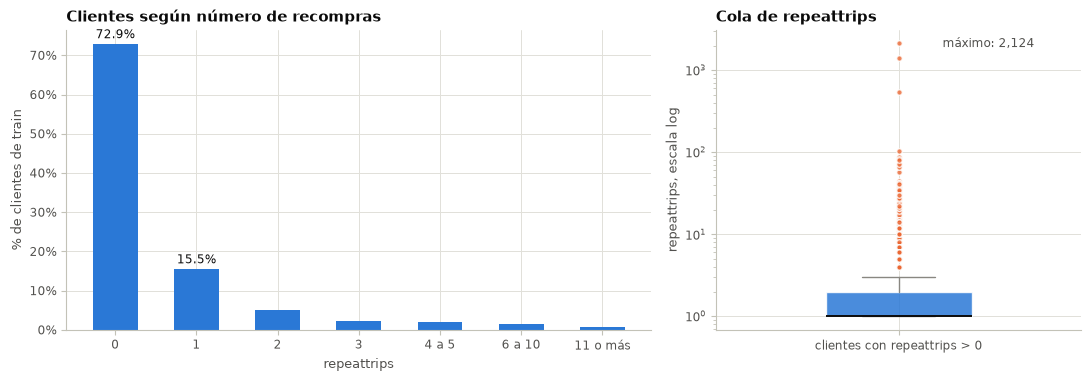

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), gridspec_kw={"width_ratios": [1.6, 1]})

axes[0].bar(frecuencias_rt.index.astype(str), frecuencias_rt["porcentaje"], color=AZUL, width=0.55)
for etiqueta in ["0", "1"]:
    valor = frecuencias_rt.loc[etiqueta, "porcentaje"]
    axes[0].text(etiqueta, valor + 1.5, f"{valor:.1f}%", ha="center", fontsize=8.5, color=TINTA)
axes[0].set_title("Clientes según número de recompras")
axes[0].set_xlabel("repeattrips")
axes[0].set_ylabel("% de clientes de train")
axes[0].yaxis.set_major_formatter(PercentFormatter(decimals=0))

recurrentes = rt[rt > 0]
caja = axes[1].boxplot(
    recurrentes, widths=0.4, patch_artist=True,
    medianprops={"color": TINTA, "linewidth": 1.4},
    whiskerprops={"color": TINTA_TENUE}, capprops={"color": TINTA_TENUE},
    flierprops={"marker": "o", "markersize": 4, "markerfacecolor": NARANJA,
                "markeredgecolor": "white", "alpha": 0.8},
)
caja["boxes"][0].set(facecolor=AZUL, alpha=0.85, edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_xticks([1], ["clientes con repeattrips > 0"])
axes[1].set_ylabel("repeattrips, escala log")
axes[1].set_title("Cola de repeattrips")
axes[1].annotate(f"máximo: {recurrentes.max():,}", xy=(1, recurrentes.max()), xytext=(1.12, recurrentes.max()),
                 va="center", fontsize=8.5, color=TINTA_SEC)

fig.tight_layout()
guardar(fig, "03_repeattrips.png")

- El 72.9% de los clientes no volvió a comprar y el 15.5% volvió exactamente una vez. Entre los que volvieron, la mediana es 1 recompra y la media 2.42; el 99% tiene 15 o menos.
- La cola es extrema: el percentil 99.9 es 30, el máximo 2,124 y la asimetría 252. Ningún hogar compra el mismo producto 2,124 veces en unos meses; la sección 8 muestra que estos casos coinciden con tarjetas de volumen imposible.
- El reto solo usa `repeater`, que es igual si `repeattrips` vale 3 o 2,124, así que estos extremos no afectan la variable objetivo. Sí impedirían usar `repeattrips` como objetivo de regresión sin tratarlos.

## 4. Variables de comportamiento: estadística descriptiva

In [10]:
variables = [c for c in COLUMNAS_GENERALES + COLUMNAS_OFERTA if not c.startswith("nunca_compro_")]
numericas = ds[variables].astype("float64")
descriptiva = numericas.describe(percentiles=[0.25, 0.5, 0.75, 0.99]).T
descriptiva.insert(1, "nulos", numericas.isna().sum())
descriptiva["pct_ceros"] = 100 * (numericas == 0).mean()
descriptiva["asimetria"] = numericas.skew()
descriptiva.to_csv(TABLES_DIR / "03_resumen_features.csv")
descriptiva.round(2)

,count,nulos,mean,std,min,25%,50%,75%,99%,max,pct_ceros,asimetria
n_lineas,160057.0,0,1168.29,11517.53,1.00,509.00,902.00,1415.00,3254.44,2647164.00,0.00,154.22
n_compras,160057.0,0,1127.90,11419.68,1.00,489.00,866.00,1359.00,3144.44,2634236.00,0.00,154.47
n_devoluciones,160057.0,0,0.99,12.27,0.00,0.00,0.00,0.00,17.00,4198.00,78.74,260.02
n_descuentos,160057.0,0,24.76,93.33,0.00,1.00,8.00,28.00,205.00,28399.00,22.73,189.73
n_visitas,160057.0,0,81.23,50.38,1.00,46.00,70.00,104.00,252.00,418.00,0.00,1.48
gasto_total,160057.0,0,5670.01,172086.59,-5953.67,2063.12,3661.75,5789.16,14069.48,48321663.59,0.00,205.95
ticket_promedio,160057.0,0,61.21,429.11,-45.80,32.81,49.79,73.77,175.34,116157.85,0.00,196.63
dias_ultima_compra,160057.0,0,8.76,9.48,1.00,4.00,6.00,10.00,48.00,305.00,0.00,4.92
antiguedad_dias,160057.0,0,384.34,47.76,1.00,382.00,391.00,412.00,422.00,424.00,0.00,-3.88
n_categorias_distintas,160057.0,0,196.49,76.41,1.00,142.00,196.00,249.00,371.00,783.00,0.00,0.31


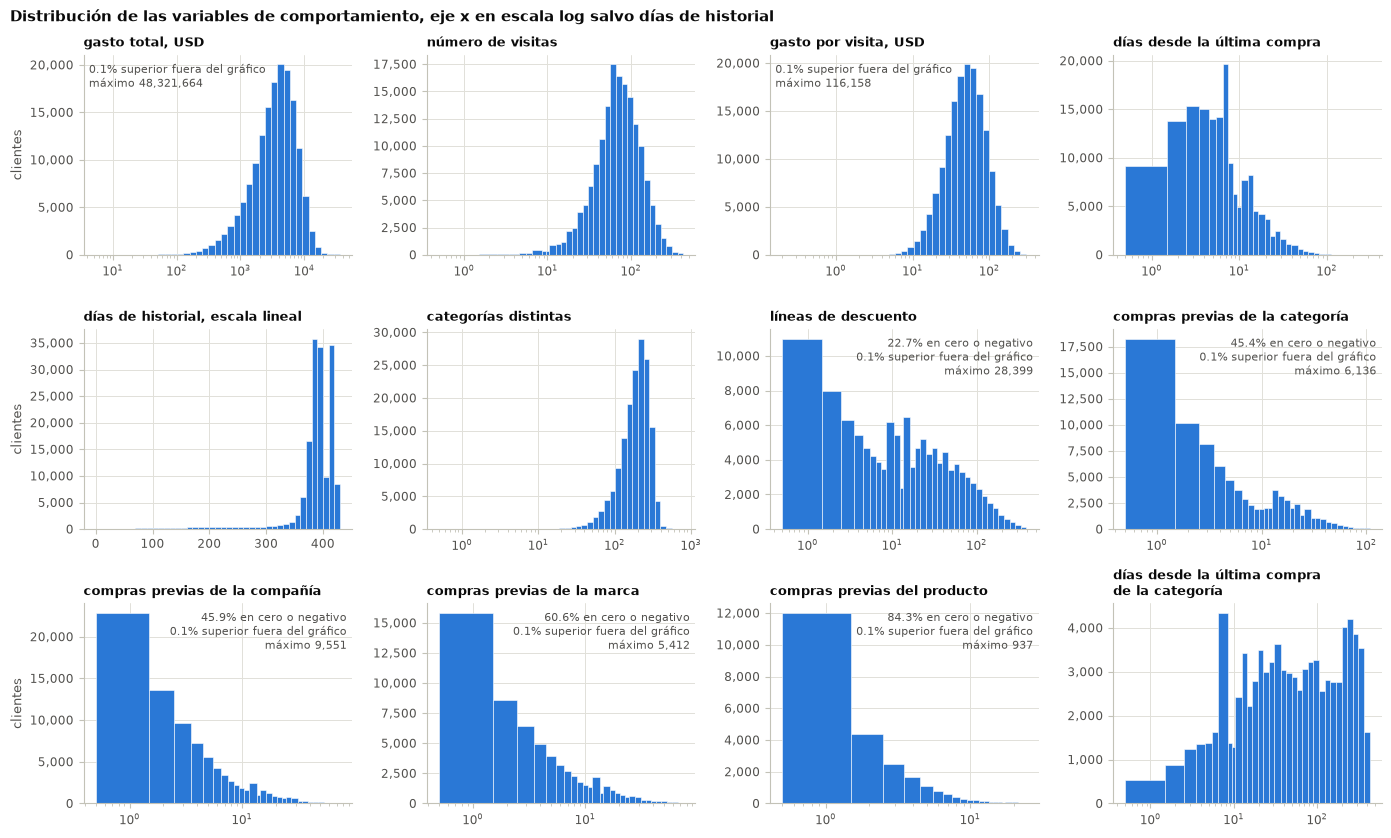

In [11]:
def bordes_log(serie, n=40):
    """Bordes geométricos; en variables enteras se alinean a medios enteros."""
    positivos = serie[serie > 0]
    bordes = np.geomspace(positivos.min(), positivos.max() * 1.01, n)
    if np.allclose(positivos, positivos.round()):
        bordes = np.unique(np.round(bordes)) + 0.5
        bordes = np.concatenate([[positivos.min() - 0.5], bordes[bordes > positivos.min()]])
    return bordes


def histograma_log(ax, serie, titulo):
    """Histograma de los valores positivos en escala log. Si la cola es extrema se corta
    en el percentil 99.9 y se anota el máximo, para que el cuerpo no quede aplastado."""
    serie = serie.dropna().astype("float64")
    notas = []
    no_positivos = (serie <= 0).mean()
    if no_positivos >= 0.001:
        notas.append(f"{no_positivos:.1%} en cero o negativo")
    corte = serie.quantile(0.999)
    if serie.max() > 10 * corte:
        notas.append(f"0.1% superior fuera del gráfico\nmáximo {serie.max():,.0f}")
        serie = serie[serie <= corte]
    conteos, bordes, _ = ax.hist(serie[serie > 0], bins=bordes_log(serie), color=AZUL, edgecolor="white", linewidth=0.4)
    ax.set_xscale("log")
    ax.set_title(titulo, fontsize=9.5)
    ax.yaxis.set_major_formatter(miles)
    if notas:
        # la nota va del lado contrario a la barra más alta
        lim_inf, lim_sup = np.log10(ax.get_xlim())
        pico = np.sqrt(bordes[np.argmax(conteos)] * bordes[np.argmax(conteos) + 1])
        centro = (np.log10(pico) - lim_inf) / (lim_sup - lim_inf)
        if centro > 0.5:
            nota(ax, "\n".join(notas), x=0.02, ha="left")
        else:
            nota(ax, "\n".join(notas))


principales = {
    "gasto_total": "gasto total, USD",
    "n_visitas": "número de visitas",
    "ticket_promedio": "gasto por visita, USD",
    "dias_ultima_compra": "días desde la última compra",
    "antiguedad_dias": "días de historial",
    "n_categorias_distintas": "categorías distintas",
    "n_descuentos": "líneas de descuento",
    "n_compras_categoria": "compras previas de la categoría",
    "n_compras_compania": "compras previas de la compañía",
    "n_compras_marca": "compras previas de la marca",
    "n_compras_producto": "compras previas del producto",
    "dias_ultima_compra_categoria": "días desde la última compra\nde la categoría",
}
fig, axes = plt.subplots(3, 4, figsize=(14, 8.5))
for ax, (col, titulo) in zip(axes.flat, principales.items()):
    if col == "antiguedad_dias":
        # casi todos los clientes tienen un año de historial: la escala log no aporta aquí
        ax.hist(ds[col], bins=np.arange(0, ds[col].max() + 10, 10), color=AZUL, edgecolor="white", linewidth=0.4)
        ax.set_title(f"{titulo}, escala lineal", fontsize=9.5)
        ax.yaxis.set_major_formatter(miles)
    else:
        histograma_log(ax, ds[col], titulo)
for ax in axes[:, 0]:
    ax.set_ylabel("clientes")
fig.suptitle("Distribución de las variables de comportamiento, eje x en escala log salvo días de historial", x=0.01, ha="left",
             fontsize=11, fontweight="bold", color=TINTA)
fig.tight_layout()
guardar(fig, "03_histogramas_features.png")

- Casi todas las variables tienen sesgo positivo marcado: la media supera a la mediana y la desviación es varias veces la media. En escala log, gasto, visitas, gasto por visita y categorías distintas se ven aproximadamente simétricas, así que el logaritmo es la transformación natural para el modelado.
- El cliente típico visitó la tienda 70 días en su historial, con la mitad central entre 46 y 104, gastó 3,662 dólares, 50 por visita, y compró de 196 categorías distintas.
- `dias_ultima_compra` tiene mediana de 6 días y un pico en 7: el 63.2% compró en la última semana antes del cupón, un patrón de compra semanal.
- `antiguedad_dias` casi no varía: el 89.1% de los clientes tiene al menos un año de historial, con mediana de 391 días. Solo 598 clientes tienen menos de 90 días.
- Las compras previas del producto ofertado son escasas: la mediana de compras de la categoría es 1 y la de la marca 0. En estas variables el cero es el valor más frecuente.
- `n_lineas`, `gasto_total` y `ticket_promedio` llegan a 2.6 millones de líneas, 48.3 millones de dólares y 116 mil dólares por visita. Son los clientes de volumen imposible de la sección 8.
- Hay 2 clientes de train con gasto neto negativo, en los que los descuentos y devoluciones superan a las compras.

## 5. Comparación entre quienes volvieron y quienes no

Diagramas de caja por clase de `repeater`, en escala log y sin puntos atípicos para que se vea el cuerpo de la distribución; los atípicos se analizan en la sección 8.

In [12]:
medianas = ds.groupby("repeater")[variables].median().T
medianas.columns = ["mediana_no_volvio", "mediana_volvio"]
medias = ds.groupby("repeater")[variables].mean().T
medianas["media_no_volvio"], medianas["media_volvio"] = medias[False], medias[True]
medianas["cociente_medias"] = medianas["media_volvio"] / medianas["media_no_volvio"]
medianas.to_csv(TABLES_DIR / "03_comparacion_por_clase.csv")
medianas.round(2)

,mediana_no_volvio,mediana_volvio,media_no_volvio,media_volvio,cociente_medias
n_lineas,881.00,965.00,1022.56,1559.54,1.53
n_compras,845.00,930.00,982.80,1517.46,1.54
n_devoluciones,0.00,0.00,0.96,1.08,1.11
n_descuentos,8.00,6.00,24.61,25.14,1.02
n_visitas,69.00,73.00,80.00,84.55,1.06
gasto_total,3556.36,3974.25,4192.05,9637.92,2.30
ticket_promedio,49.19,51.58,56.92,72.73,1.28
dias_ultima_compra,6.00,6.00,9.01,8.09,0.90
antiguedad_dias,390.00,395.00,383.90,385.51,1.00
n_categorias_distintas,195.00,198.00,195.60,198.89,1.02


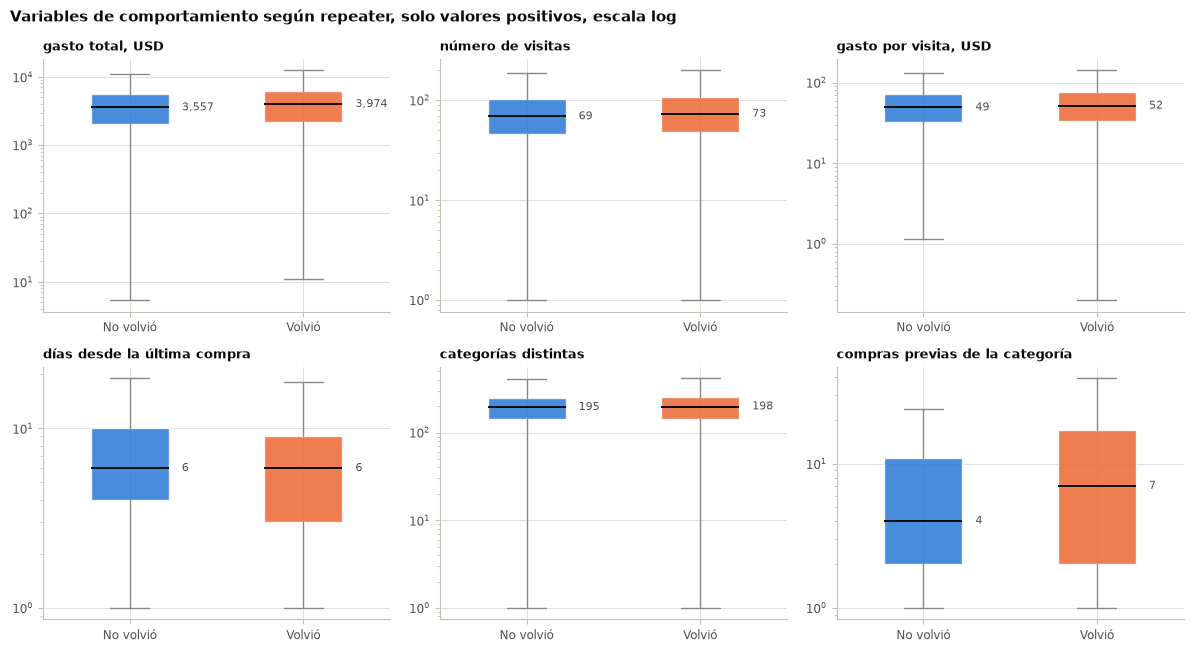

In [13]:
por_clase = {
    "gasto_total": "gasto total, USD",
    "n_visitas": "número de visitas",
    "ticket_promedio": "gasto por visita, USD",
    "dias_ultima_compra": "días desde la última compra",
    "n_categorias_distintas": "categorías distintas",
    "n_compras_categoria": "compras previas de la categoría",
}
fig, axes = plt.subplots(2, 3, figsize=(12, 6.6))
for ax, (col, titulo) in zip(axes.flat, por_clase.items()):
    datos = [ds.loc[(ds["repeater"] == clase) & (ds[col] > 0), col] for clase in (False, True)]
    caja = ax.boxplot(
        datos, tick_labels=[ETIQUETA_CLASE[False], ETIQUETA_CLASE[True]], widths=0.45,
        patch_artist=True, showfliers=False,
        medianprops={"color": TINTA, "linewidth": 1.4},
        whiskerprops={"color": TINTA_TENUE}, capprops={"color": TINTA_TENUE},
    )
    for parche, clase in zip(caja["boxes"], (False, True)):
        parche.set(facecolor=COLOR_CLASE[clase], alpha=0.85, edgecolor="white")
    for posicion, d in enumerate(datos, start=1):
        ax.text(posicion + 0.3, d.median(), f"{d.median():,.0f}", va="center", fontsize=8, color=TINTA_SEC)
    ax.set_yscale("log")
    ax.set_title(titulo, fontsize=9.5)
fig.suptitle("Variables de comportamiento según repeater, solo valores positivos, escala log",
             x=0.01, ha="left", fontsize=11, fontweight="bold", color=TINTA)
fig.tight_layout()
guardar(fig, "03_boxplots_por_clase.png")

- En las variables generales las distribuciones de ambas clases casi se superponen. Las medianas de quienes volvieron son apenas mayores: gasto de 3,974 contra 3,557 dólares, 73 contra 69 visitas y 51.6 contra 49.2 dólares por visita.
- Las medias difieren más, 9,638 contra 4,192 dólares de gasto, pero esa diferencia la producen unos pocos clientes extremos que vuelven a comprar con más frecuencia; la mediana es la comparación confiable.
- La diferencia clara está en la categoría ofertada: entre quienes ya la compraban, la mediana es 7 compras en los que volvieron contra 4 en los que no. En promedio, los que volvieron habían comprado la categoría 2.2 veces más y el producto exacto 3 veces más.

### Tasa de recompra por segmentos

Siguiendo el modelo RFM, se divide a los clientes en quintiles de recencia, frecuencia y monto y se calcula la tasa de recompra en cada quintil. El quintil 1 tiene los valores más bajos de la variable: en recencia son los clientes que compraron más recientemente.

In [14]:
rfm = {
    "dias_ultima_compra": "recencia: días desde la última compra",
    "n_visitas": "frecuencia: número de visitas",
    "gasto_total": "monto: gasto total",
}


def quintiles(col):
    return pd.qcut(ds[col].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])


tasa_quintil = pd.DataFrame({col: ds.groupby(quintiles(col), observed=True)["repeater"].mean() for col in rfm})
rangos_quintil = pd.DataFrame(
    {f"{col}_rango": ds.groupby(quintiles(col), observed=True)[col].agg(lambda s: f"{s.min():,.0f} a {s.max():,.0f}") for col in rfm}
)
tabla_quintiles = tasa_quintil.add_prefix("tasa_").join(rangos_quintil)
tabla_quintiles.index.name = "quintil"
tabla_quintiles.to_csv(TABLES_DIR / "03_tasa_recompra_quintiles_rfm.csv")
tabla_quintiles

,tasa_dias_ultima_compra,tasa_n_visitas,tasa_gasto_total,dias_ultima_compra_rango,n_visitas_rango,gasto_total_rango
quintil,,,,,,
1,0.288267,0.253061,0.257560,1 a 3,1 a 41,"-5,954 a 1,743"
2,0.276780,0.250570,0.238168,3 a 5,41 a 60,"1,743 a 2,996"
3,0.278748,0.273250,0.254569,5 a 7,60 a 81,"2,996 a 4,399"
4,0.274437,0.281185,0.279373,7 a 12,81 a 115,"4,399 a 6,407"
5,0.238723,0.298888,0.327284,12 a 305,115 a 418,"6,407 a 48,321,664"


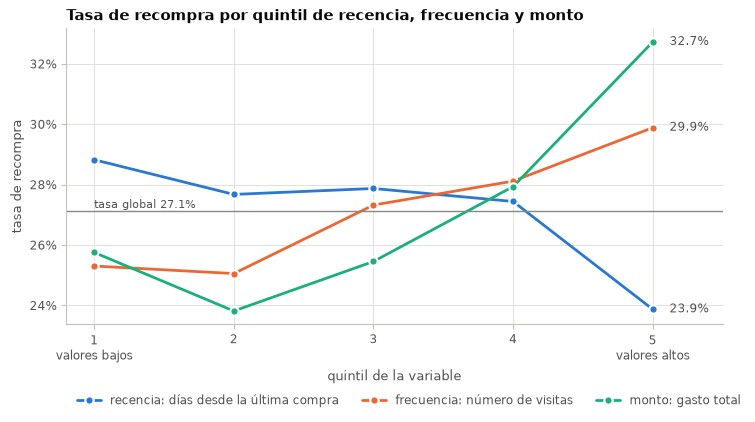

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.4))
for (col, etiqueta), color in zip(rfm.items(), [AZUL, NARANJA, AQUA]):
    ax.plot(tasa_quintil.index.astype(int), tasa_quintil[col], color=color, marker="o", markersize=6,
            markeredgecolor="white", markeredgewidth=1.5, label=etiqueta)
    ax.text(5.12, tasa_quintil[col].iloc[-1], f"{tasa_quintil[col].iloc[-1]:.1%}", va="center", fontsize=8.5, color=TINTA_SEC)
ax.axhline(tasa_global, color=TINTA_TENUE, linewidth=1)
ax.text(1, tasa_global, f"tasa global {tasa_global:.1%}", va="bottom", fontsize=8, color=TINTA_SEC)
ax.set_xticks([1, 2, 3, 4, 5], ["1\nvalores bajos", "2", "3", "4", "5\nvalores altos"])
ax.set_xlim(0.8, 5.5)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel("tasa de recompra")
ax.set_xlabel("quintil de la variable")
ax.set_title("Tasa de recompra por quintil de recencia, frecuencia y monto")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.2), ncol=3)
fig.tight_layout()
guardar(fig, "03_tasa_recompra_rfm.png")

- **Monto:** es el que más separa. El quintil de mayor gasto, más de 6,407 dólares, tiene una tasa de 32.7% contra 23.8% del segundo quintil, 8.9 puntos de diferencia.
- **Frecuencia:** la tasa sube de 25.3% en el quintil con menos visitas a 29.9% en el de más visitas.
- **Recencia:** va en el sentido que predice RFM. Quienes compraron en los últimos 3 días tienen 28.8% y quienes llevaban 12 días o más sin comprar, 23.9%.
- Ninguna de las tres mueve la tasa más de unos 9 puntos alrededor del 27.1% global. Coincide con lo esperado en la investigación: la señal existe pero es débil, y el modelo tendrá que combinar variables.

### Tasa de recompra según compras previas del producto ofertado

In [16]:
dimensiones = {"categoria": "categoría", "compania": "compañía", "marca": "marca", "producto": "producto exacto"}
filas = []
for dim, nombre in dimensiones.items():
    nunca = ds[f"nunca_compro_{dim}"] == 1
    filas.append(
        {
            "dimension": nombre,
            "pct_clientes_con_compra_previa": 100 * (~nunca).mean(),
            "tasa_con_compra_previa": ds.loc[~nunca, "repeater"].mean(),
            "tasa_sin_compra_previa": ds.loc[nunca, "repeater"].mean(),
        }
    )
compra_previa = pd.DataFrame(filas).set_index("dimension")
compra_previa["diferencia_puntos"] = 100 * (compra_previa["tasa_con_compra_previa"] - compra_previa["tasa_sin_compra_previa"])
compra_previa.to_csv(TABLES_DIR / "03_tasa_recompra_compra_previa.csv")
compra_previa.round(3)

,pct_clientes_con_compra_previa,tasa_con_compra_previa,tasa_sin_compra_previa,diferencia_puntos
dimension,,,,
categoría,54.617,0.323,0.209,11.422
compañía,54.102,0.269,0.274,-0.473
marca,39.397,0.303,0.251,5.152
producto exacto,15.696,0.428,0.242,18.604


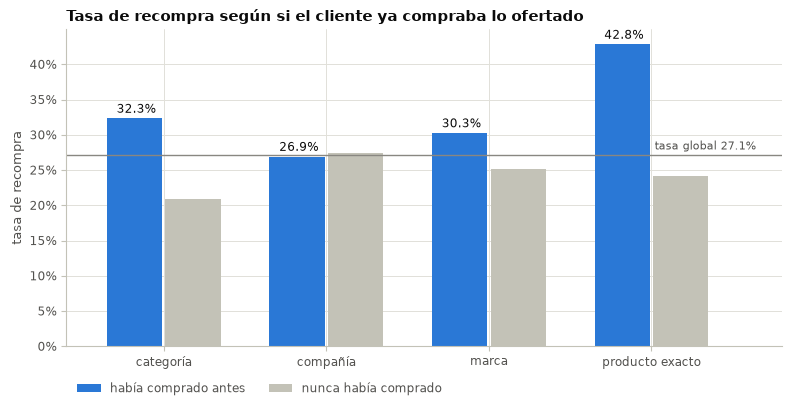

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(compra_previa))
ancho = 0.34
ax.bar(x - ancho / 2 - 0.01, compra_previa["tasa_con_compra_previa"], width=ancho, color=AZUL, label="había comprado antes")
ax.bar(x + ancho / 2 + 0.01, compra_previa["tasa_sin_compra_previa"], width=ancho, color=GRIS, label="nunca había comprado")
for i, valor in enumerate(compra_previa["tasa_con_compra_previa"]):
    ax.text(i - ancho / 2, valor + 0.008, f"{valor:.1%}", ha="center", fontsize=8.5, color=TINTA)
ax.axhline(tasa_global, color=TINTA_TENUE, linewidth=1)
ax.text(len(compra_previa) - 0.98, tasa_global + 0.004, f"tasa global {tasa_global:.1%}", ha="left", va="bottom", fontsize=8, color=TINTA_SEC)
ax.set_xlim(-0.6, len(compra_previa) - 0.2)
ax.set_xticks(x, compra_previa.index)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel("tasa de recompra")
ax.set_title("Tasa de recompra según si el cliente ya compraba lo ofertado")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.08), ncol=2)
fig.tight_layout()
guardar(fig, "03_tasa_recompra_compra_previa.png")

- Haber comprado antes **el producto exacto** es la señal individual más fuerte encontrada: 42.8% de recompra contra 24.2%, 18.6 puntos de diferencia, aunque solo aplica al 15.7% de los clientes.
- Haber comprado la **categoría** sube la tasa de 20.9% a 32.3%, 11.4 puntos, y cubre al 54.6% de los clientes. La **marca** suma 5.2 puntos.
- Haber comprado a la **compañía** no cambia nada: 26.9% contra 27.4%. Una compañía fabrica productos de muchas categorías, así que haberle comprado no dice nada del producto ofertado.
- La hipótesis de la investigación se confirma para categoría, marca y producto: el cliente que ya conocía lo ofertado vuelve con más frecuencia.

## 6. Gráficos de dispersión

Con 160 mil clientes un scatter simple se satura, así que se usa un gráfico de hexágonos: el color indica cuántos clientes caen en cada celda. En el título va la correlación de Spearman, que mide asociación monótona y no se ve afectada por la escala ni por los extremos.

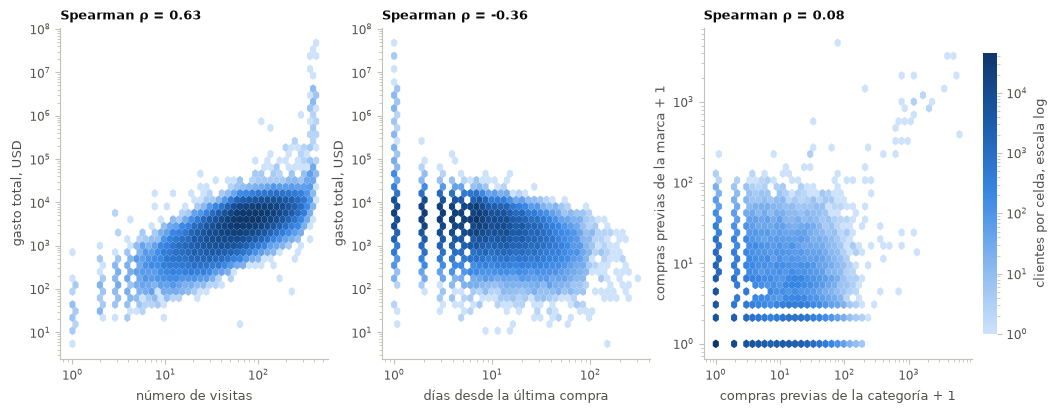

In [18]:
pares = [
    ("n_visitas", "gasto_total", "número de visitas", "gasto total, USD", 0),
    ("dias_ultima_compra", "gasto_total", "días desde la última compra", "gasto total, USD", 0),
    ("n_compras_categoria", "n_compras_marca", "compras previas de la categoría + 1", "compras previas de la marca + 1", 1),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for ax, (x, y, etiqueta_x, etiqueta_y, desplazamiento) in zip(axes, pares):
    datos = ds[[x, y]].dropna().astype("float64") + desplazamiento
    datos = datos[(datos[x] > 0) & (datos[y] > 0)]
    rho = ds[[x, y]].corr(method="spearman").iloc[0, 1]
    celdas = ax.hexbin(datos[x], datos[y], gridsize=40, xscale="log", yscale="log", bins="log",
                       cmap=SECUENCIAL, mincnt=1, linewidths=0)
    ax.set_xlabel(etiqueta_x)
    ax.set_ylabel(etiqueta_y)
    ax.set_title(f"Spearman ρ = {rho:.2f}", fontsize=9.5)
    ax.grid(False)
barra = fig.colorbar(celdas, ax=axes, shrink=0.85, pad=0.01)
barra.set_label("clientes por celda, escala log", color=TINTA_SEC)
barra.outline.set_visible(False)
guardar(fig, "03_dispersion.png")

- Visitas y gasto total tienen una correlación de Spearman de 0.63: quien visita más gasta más. En el extremo superior aparece una columna de clientes con más de 300 visitas y gastos de millones, los atípicos de la sección 8.
- Días desde la última compra y gasto total tienen correlación de -0.36: los que gastan más compraron más recientemente. Recencia, frecuencia y monto están relacionadas y en parte son redundantes.
- Las compras previas de la categoría y de la marca apenas se relacionan, 0.08: muchos clientes compran la categoría sin comprar la marca ofertada, así que ambas variables aportan información distinta.

## 7. Faltantes

El notebook 02 dejó los conteos y montos en cero cuando el cliente no tenía compras previas, porque ahí el cero es un valor real. Las únicas columnas con vacíos son las de recencia, y se revisa a quién corresponden.

In [19]:
faltantes = ds.isna().sum()
faltantes = faltantes[faltantes > 0].rename("faltantes").to_frame()
faltantes["porcentaje"] = (100 * faltantes["faltantes"] / len(ds)).round(2)
faltantes["tasa_recompra_con_faltante"] = [ds.loc[ds[c].isna(), "repeater"].mean() for c in faltantes.index]
faltantes["tasa_recompra_sin_faltante"] = [ds.loc[ds[c].notna(), "repeater"].mean() for c in faltantes.index]
faltantes.to_csv(TABLES_DIR / "03_faltantes.csv")
faltantes.round(3)

,faltantes,porcentaje,tasa_recompra_con_faltante,tasa_recompra_sin_faltante
dias_ultima_compra_categoria,72639,45.38,0.209,0.323


In [20]:
vacio_categoria = ds["dias_ultima_compra_categoria"].isna()
print("vacío en dias_ultima_compra_categoria y nunca_compro_categoria = 1:",
      (vacio_categoria == (ds["nunca_compro_categoria"] == 1)).all())

vacío en dias_ultima_compra_categoria y nunca_compro_categoria = 1: True


- `dias_ultima_compra_categoria` es la única variable con vacíos, el 45.38% de los clientes, y el vacío coincide exactamente con `nunca_compro_categoria = 1`.
- El vacío es informativo: esos clientes vuelven a comprar el 20.9% de las veces, contra 32.3% de quienes tienen el dato. Eliminar esas filas o imputar la media borraría justamente esta diferencia; por eso se conservan el vacío y la bandera.

## 8. Valores atípicos

Primero se aplica la regla de Tukey a cada variable: es atípico lo que queda por encima de Q3 + 1.5·IQR. En distribuciones con sesgo tan marcado esa regla marca a una fracción grande de clientes, así que después se buscan los casos que no son solo altos sino imposibles para un hogar.

In [21]:
tukey = []
for col in ["n_lineas", "n_visitas", "gasto_total", "ticket_promedio", "n_categorias_distintas",
            "n_compras_categoria", "n_compras_marca", "n_compras_producto", "repeattrips"]:
    serie = ds[col].astype("float64")
    q1, q3 = serie.quantile([0.25, 0.75])
    limite = q3 + 1.5 * (q3 - q1)
    tukey.append({"variable": col, "q1": q1, "q3": q3, "limite_superior": limite,
                  "atipicos": int((serie > limite).sum()), "pct_atipicos": 100 * (serie > limite).mean(),
                  "maximo": serie.max()})
tukey = pd.DataFrame(tukey).set_index("variable")
tukey.to_csv(TABLES_DIR / "03_atipicos_tukey.csv")
tukey.round(2)

,q1,q3,limite_superior,atipicos,pct_atipicos,maximo
variable,,,,,,
n_lineas,509.00,1415.00,2774.00,3817,2.38,2647164.00
n_visitas,46.00,104.00,191.00,5973,3.73,418.00
gasto_total,2063.12,5789.16,11378.22,4372,2.73,48321663.59
ticket_promedio,32.81,73.77,135.21,5628,3.52,116157.85
n_categorias_distintas,142.00,249.00,409.50,517,0.32,783.00
n_compras_categoria,0.00,6.00,15.00,17814,11.13,6136.00
n_compras_marca,0.00,2.00,5.00,23292,14.55,5412.00
n_compras_producto,0.00,0.00,0.00,25122,15.70,937.00
repeattrips,0.00,1.00,2.50,10427,6.51,2124.00


In [22]:
ds["meses_historial"] = ds["antiguedad_dias"].clip(lower=1) / 30.44
ds["lineas_por_mes"] = ds["n_lineas"] / ds["meses_historial"]
ds["lineas_por_visita"] = ds["n_lineas"] / ds["n_visitas"].where(ds["n_visitas"] > 0)
ds[["lineas_por_mes", "lineas_por_visita", "n_visitas"]].describe(percentiles=[0.5, 0.9, 0.99, 0.999]).round(1)

,lineas_por_mes,lineas_por_visita,n_visitas
count,160057.0,160057.0,160057.0
mean,92.3,14.1,81.2
std,885.8,30.1,50.4
min,0.4,1.0,1.0
50%,71.3,12.1,70.0
90%,151.8,24.0,146.0
99%,247.8,40.0,252.0
99.9%,750.0,62.4,356.0
max,193236.6,6363.4,418.0


In [23]:
# Un hogar que compra todos los días rara vez supera unas pocas decenas de artículos por visita.
# Se marca como volumen extremo lo que supera el percentil 99.9 de líneas por mes.
UMBRAL_LINEAS_MES = ds["lineas_por_mes"].quantile(0.999)
extremo = ds["lineas_por_mes"] > UMBRAL_LINEAS_MES
print(f"umbral: {UMBRAL_LINEAS_MES:,.0f} líneas por mes | clientes marcados: {extremo.sum()}")

perfil_extremos = pd.DataFrame(
    {
        "volumen_extremo": ds[extremo][["n_lineas", "n_visitas", "lineas_por_mes", "lineas_por_visita",
                                        "gasto_total", "n_categorias_distintas", "repeattrips"]].median(),
        "resto": ds[~extremo][["n_lineas", "n_visitas", "lineas_por_mes", "lineas_por_visita",
                               "gasto_total", "n_categorias_distintas", "repeattrips"]].median(),
    }
)
perfil_extremos.loc["tasa_recompra"] = [ds.loc[extremo, "repeater"].mean(), ds.loc[~extremo, "repeater"].mean()]
perfil_extremos.loc["clientes"] = [extremo.sum(), (~extremo).sum()]
perfil_extremos.to_csv(TABLES_DIR / "03_perfil_volumen_extremo.csv")
perfil_extremos.round(2)

umbral: 750 líneas por mes | clientes marcados: 161


,volumen_extremo,resto
n_lineas,15610.00,901.00
n_visitas,371.00,70.00
lineas_por_mes,2226.71,71.21
lineas_por_visita,88.19,12.10
gasto_total,59342.06,3658.26
n_categorias_distintas,608.00,196.00
repeattrips,1.00,0.00
tasa_recompra,0.60,0.27
clientes,161.00,159896.00


In [24]:
columnas_extremos = ["id", "chain", "offer", "n_lineas", "n_visitas", "lineas_por_mes", "lineas_por_visita",
                     "gasto_total", "repeattrips"]
top_repeattrips = ds.nlargest(10, "repeattrips")[columnas_extremos]
top_repeattrips.to_csv(TABLES_DIR / "03_top_repeattrips.csv", index=False)
top_repeattrips.round(1)

,id,chain,offer,n_lineas,n_visitas,lineas_por_mes,lineas_por_visita,gasto_total,repeattrips
123859,3465135195,306,1197502,1414122,387,110943.0,3654.1,24120833.8,2124
123678,3450535153,306,1197502,3155,289,233.1,10.9,194324.9,1418
140693,4427711419,152,1203052,137472,111,37362.9,1238.5,843069.0,549
138102,4176323168,166,1203052,45253,196,5668.7,230.9,202978.2,104
7839,239276354,116,1197502,346795,412,25498.6,841.7,2339561.0,87
63002,618764932,166,1200988,1985478,382,158214.5,5197.6,28756411.9,82
160038,4683851813,166,1203052,1109,3,5626.3,369.7,6559.0,80
140490,4389020404,233,1197502,83533,139,18162.5,601.0,459654.1,72
148319,4625744661,152,1208329,2871,366,210.1,7.8,12807.5,71
136700,4083461977,166,1203052,52854,259,5345.1,204.1,261426.3,70


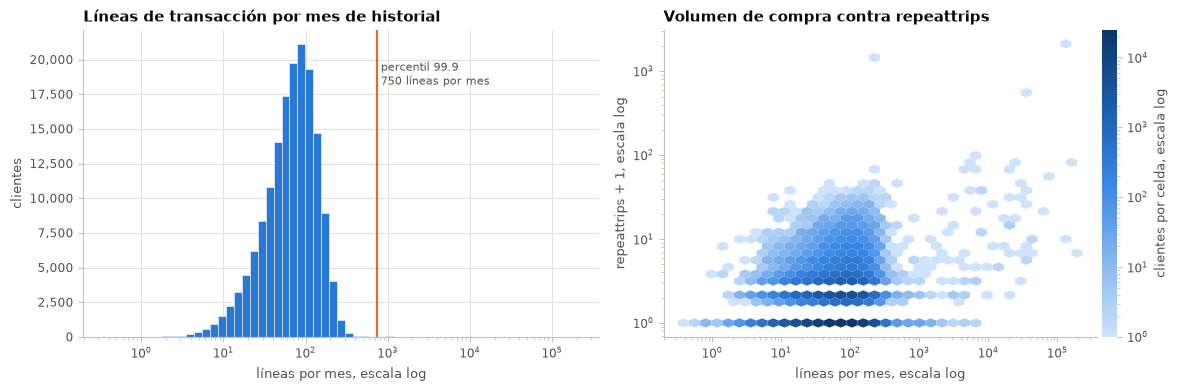

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

serie = ds["lineas_por_mes"].dropna()
serie = serie[serie > 0]
axes[0].hist(serie, bins=np.geomspace(serie.min(), serie.max(), 60), color=AZUL, edgecolor="white", linewidth=0.4)
axes[0].set_xscale("log")
axes[0].axvline(UMBRAL_LINEAS_MES, color=NARANJA, linewidth=1.5)
axes[0].text(UMBRAL_LINEAS_MES * 1.1, axes[0].get_ylim()[1] * 0.9, f"percentil 99.9\n{UMBRAL_LINEAS_MES:,.0f} líneas por mes",
             fontsize=8, color=TINTA_SEC, va="top")
axes[0].set_title("Líneas de transacción por mes de historial")
axes[0].set_xlabel("líneas por mes, escala log")
axes[0].set_ylabel("clientes")
axes[0].yaxis.set_major_formatter(miles)

celdas = axes[1].hexbin(ds["lineas_por_mes"].clip(lower=0.1), ds["repeattrips"] + 1, gridsize=35,
                        xscale="log", yscale="log", bins="log", cmap=SECUENCIAL, mincnt=1, linewidths=0)
axes[1].set_title("Volumen de compra contra repeattrips")
axes[1].set_xlabel("líneas por mes, escala log")
axes[1].set_ylabel("repeattrips + 1, escala log")
axes[1].grid(False)
barra = fig.colorbar(celdas, ax=axes[1], pad=0.01)
barra.set_label("clientes por celda, escala log", color=TINTA_SEC)
barra.outline.set_visible(False)

fig.tight_layout()
guardar(fig, "03_atipicos_volumen.png")

- La regla de Tukey marca entre 2% y 4% de los clientes en las variables generales, y hasta 16% en las compras previas del producto. En estas últimas Q3 es 0 o muy bajo, así que cualquier compra ya cuenta como atípica: la regla no sirve en distribuciones tan concentradas en cero.
- El criterio útil es el volumen imposible. El percentil 99.9 de líneas por mes es 750, cuando la mediana es 71. Los 161 clientes por encima tienen en mediana 15,610 líneas, 88 artículos por visita y 59,342 dólares de gasto; el más extremo registra 1.4 millones de líneas, 3,654 artículos por visita y 24 millones de dólares. Como anticipaba la investigación, parecen tarjetas compartidas o de la propia tienda más que personas.
- Estos clientes explican la cola de `repeattrips`: 10 de los 12 clientes con 50 o más recompras están en este grupo, y su tasa de recompra es 59.6% contra 27.1% del resto. Se concentran en pocas cadenas: la 224, la 166 y la 205 suman 70 de los 161.
- **Decisión:** no se eliminan. Son el 0.1% de train, también existen en test y hay que predecirlos igual. Se documentan, los gráficos usan escala log y medidas robustas, y para el modelado se recomienda una bandera de volumen extremo o transformar las variables con logaritmo.

## 9. Comparabilidad entre train y test

Las variables se construyeron igual para los clientes de test. Aquí se compara si ambos conjuntos se parecen, porque un modelo entrenado con train solo sirve si test se comporta de forma similar.

In [26]:
ds_test = res["dataset_test"]
comparar = [
    "antiguedad_dias", "n_visitas", "gasto_total", "ticket_promedio", "dias_ultima_compra",
    "n_compras_categoria", "n_compras_categoria_90d", "n_compras_marca",
    "nunca_compro_categoria", "nunca_compro_marca",
]
train_vs_test = pd.DataFrame(
    {
        "mediana_train": ds[comparar].median(),
        "mediana_test": ds_test[comparar].median(),
        "media_train": ds[comparar].mean(),
        "media_test": ds_test[comparar].mean(),
    }
)
train_vs_test.to_csv(TABLES_DIR / "03_train_vs_test.csv")

ofertas_compartidas = set(ds["offer"]) & set(ds_test["offer"])
print(f"ofertas de test que también están en train: {len(ofertas_compartidas)} de {ds_test['offer'].nunique()}")
print(f"clientes de test con una oferta que también está en train: {ds_test['offer'].isin(ofertas_compartidas).mean():.1%}")
train_vs_test.round(3)

ofertas de test que también están en train: 16 de 29
clientes de test con una oferta que también está en train: 3.7%


,mediana_train,mediana_test,media_train,media_test
antiguedad_dias,391.00,471.00,384.339,422.441
n_visitas,70.00,75.00,81.234,89.080
gasto_total,3661.75,3435.42,5670.009,4367.207
ticket_promedio,49.79,44.18,61.214,52.824
dias_ultima_compra,6.00,6.00,8.758,9.134
n_compras_categoria,1.00,3.00,5.671,4.035
n_compras_categoria_90d,0.00,0.00,1.328,0.872
n_compras_marca,0.00,0.00,2.918,2.201
nunca_compro_categoria,0.00,0.00,0.454,0.185
nunca_compro_marca,1.00,1.00,0.606,0.571


- Solo el 3.7% de los clientes de test recibió una oferta que también aparece en train. La identidad de la oferta y las tasas calculadas por oferta prácticamente no se pueden trasladar a test.
- Los clientes de test tienen 80 días más de historial en la mediana, 471 contra 391, porque sus cupones son posteriores. Tienen más visitas, 75 contra 70, pero menos gasto por visita, 44 contra 50 dólares.
- El 18.5% de los clientes de test nunca compró la categoría de su oferta, contra 45.4% en train: las ofertas de test son de categorías más comunes. En cambio las compras en ventanas fijas son menores, 0.87 contra 1.33 compras de la categoría en los 90 días previos en promedio.
- Consecuencia para el modelado: validar solo con un corte temporal dentro de train no refleja este cambio. Conviene validar dejando fuera ofertas completas y preferir variables relativas, como ventanas fijas o proporciones, sobre conteos acumulados que crecen con la longitud del historial.

## Resumen de hallazgos

1. **Lo que más se asocia con la recompra es el historial con el producto ofertado.** Haber comprado el producto exacto sube la tasa de 24.2% a 42.8% y haber comprado la categoría de 20.9% a 32.3%. Haber comprado a la compañía no aporta nada.
2. **Las variables RFM tienen señal débil.** El monto y la frecuencia se asocian positivamente con la recompra y la recencia negativamente, pero ninguna mueve la tasa más de 9 puntos alrededor del 27.1% global. El modelo tendrá que combinarlas.
3. **Todas las variables de conteo y monto tienen sesgo positivo fuerte.** Se describen con mediana y percentiles, se grafican en escala log y conviene transformarlas con logaritmo para modelar.
4. **161 clientes de volumen imposible,** el 0.1%, concentran las colas de gasto, líneas y `repeattrips` y recompran el 59.6% de las veces. Se conservan y se recomienda marcarlos con una bandera.
5. **Los faltantes son informativos.** Solo `dias_ultima_compra_categoria` tiene vacíos, el 45.4%, y corresponden a clientes sin historial de la categoría, que recompran mucho menos.
6. **Test no se parece a train.** El 96.3% de los clientes de test tiene ofertas que no existen en train y 80 días más de historial. La validación debe agrupar por oferta y las variables deben ser comparables entre periodos.